## Simple Linear Regression Model :- Predicting sunday newspaper circulation based on weekly newspaper circulation

#### Can daily newspaper circulation help predict Sunday circulation?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm

In [6]:
# Load Dataset
df = pd.read_csv("NewspaperData.csv")

In [7]:
# Display First 5 Rows
print(df.head())

            Newspaper    daily   sunday
0       Baltimore Sun  391.952  488.506
1        Boston Globe  516.981  798.298
2       Boston Herald  355.628  235.084
3  Charlotte Observer  238.555  299.451
4   Chicago Sun Times  537.780  559.093


### Dataset contains newspaper names, daily circulation, and Sunday circulation.

In [8]:
# Data Understanding
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Newspaper  34 non-null     object 
 1   daily      34 non-null     float64
 2   sunday     34 non-null     float64
dtypes: float64(2), object(1)
memory usage: 948.0+ bytes
None


In [9]:
print(df.describe())

             daily       sunday
count    34.000000    34.000000
mean    430.962471   591.202412
std     269.211470   376.418051
min     133.239000   202.614000
25%     233.021500   327.769500
50%     355.235500   436.712500
75%     516.616500   699.735250
max    1209.225000  1762.015000


#### Insight
Entries : 34.
No missing values.
Daily and Sunday are numerical variables.
Newspaper is a categorical identifier.

In [10]:
# Check Missing Values
print(df.isnull().sum())

Newspaper    0
daily        0
sunday       0
dtype: int64


In [11]:
# Correlation Analysis
correlation = df['daily'].corr(df['sunday'])
print("Correlation:", correlation)

Correlation: 0.9581543140785462


#### strong positive relationship

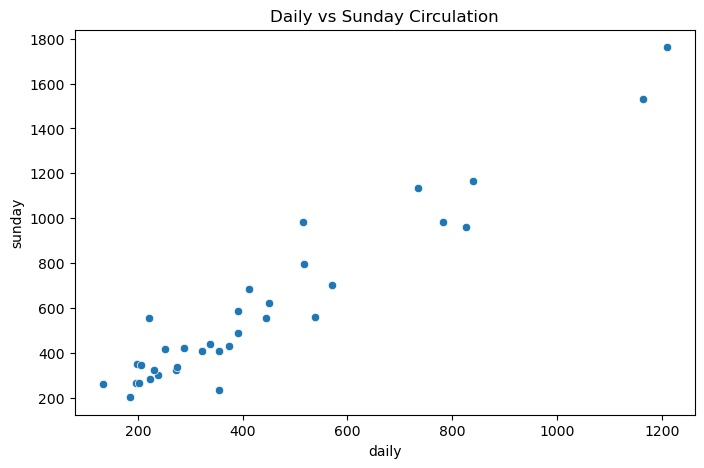

In [12]:
# Visualization
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='daily',
    y='sunday',
    data=df
)
plt.title("Daily vs Sunday Circulation")
plt.show()

### Insight 
Linear Regression is appropriate

In [13]:
# Define X and y
X = df[['daily']]
y = df['sunday']

In [14]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Insight
80% training
20% testing

In [15]:
# Train Simple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
# find Best Fit Line Equation
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

print(f"Equation: Sunday = {slope:.3f} * Daily + {intercept:.3f}")

Slope: 1.3799120726075471
Intercept: -0.135416851354762
Equation: Sunday = 1.380 * Daily + -0.135


### Insight
The slope is 1.38.
- This means for every 1-unit increase in daily circulation, Sunday circulation increases by approximately 1.38 units.
- The positive slope indicates a strong positive relationship between daily and Sunday circulation.
- Newspapers with higher weekday circulation generally tend to have higher Sunday circulation.

In [17]:
# Predictions
y_pred = model.predict(X_test)
print(y_pred[:5])

[ 569.59026048 1138.99855803  515.96411751  183.72268779  284.40797217]


#### Insight
These are the model's estimated Sunday circulation values.

In [18]:
# Model Evaluation
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("R2 Score :", r2)
print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)

R2 Score : 0.7977778942032527
MSE : 9927.761935056618
RMSE : 99.63815501632203
MAE : 89.09039005215206


### Insight

- R2 SCORE
The model explains approximately 79.8% of the variation in Sunday circulation.
This indicates strong predictive performance.
Daily circulation is an important predictor of Sunday circulation.

- MSE
MSE penalizes larger errors and is mainly useful for comparing models

- RMSE
On average, predictions differ from actual Sunday circulation by about 100 units.

- MAE
The average absolute prediction error is approximately 89 units

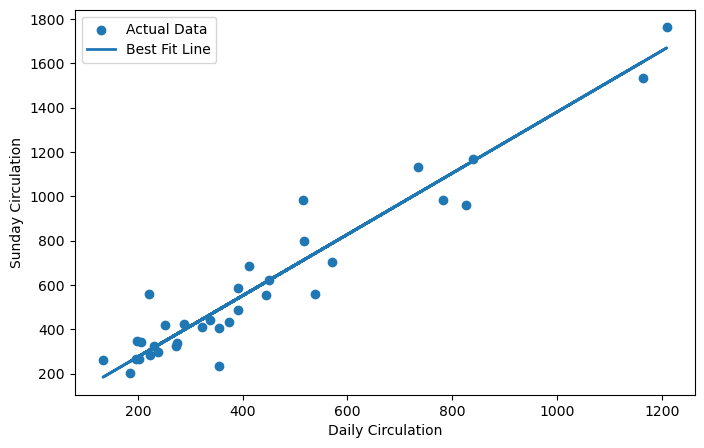

In [19]:
# Plot Best Fit Line
plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    linewidth=2,
    label="Best Fit Line"
)

plt.xlabel("Daily Circulation")
plt.ylabel("Sunday Circulation")

plt.legend()

plt.show()

### INSIGHT
Good fit because points close to line.Daily circulation explains Sunday circulation well.
Positive upward slope meaning Higher Daily Circulation -> Higher Sunday Circulation.
few extreme points The model is reasonably reliable.

In [20]:
# Statistical Significance (P-value and T-value)
X_stats = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X_stats
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 sunday   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     358.5
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           6.02e-19
Time:                        17:35:53   Log-Likelihood:                -206.85
No. Observations:                  34   AIC:                             417.7
Df Residuals:                      32   BIC:                             420.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.8356     35.804      0.386      0.7

# Insights
0.000 < 0.05
The relationship between Daily and Sunday circulation is statistically significant.
Reject the null hypothesis.

Hypothesis
H₀:
Daily circulation has no effect on Sunday circulation.
H₁:
Daily circulation significantly affects Sunday circulation.

Result:Reject H₀,Accept H₁
    
T-value
t = 18.935    
A very large t-value indicates that Daily circulation is a highly important predictor of Sunday circulation.

F-statistic
358.5
The overall regression model is statistically significant.

Business Insights

- There is a strong positive relationship between daily and Sunday newspaper circulation.
- Daily circulation alone explains nearly 80% of the variation in Sunday circulation.
- Statistical testing confirms that daily circulation significantly influences Sunday circulation.
- Newspapers with larger weekday readership generally maintain larger Sunday readership.
- Publishers can use weekday circulation data to estimate expected Sunday demand.

### CONCLUSION
This study used Simple Linear Regression to investigate the relationship between daily newspaper circulation and Sunday newspaper circulation. Correlation analysis showed a strong positive relationship between the variables. The regression model achieved an R² score of 0.798, indicating that approximately 79.8% of the variation in Sunday circulation can be explained by daily circulation. Statistical analysis using OLS regression confirmed that the relationship is highly significant (p < 0.05). The findings suggest that daily circulation is a strong predictor of Sunday circulation and can be used for forecasting and planning purposes.